In [1]:
!pwd

/Users/oliviachoi/Documents/GitHub


In [6]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect("Spring2026_IndustryProject/developer_project.duckdb")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [7]:
con.execute("""SHOW TABLES""").fetchdf()

,name
0,activity_base
1,activity_clean
2,activity_final
3,activity_raw
4,activity_score_mapping_clean
5,activity_score_mapping_raw
6,activity_work
7,contact_clean
8,contact_clean_backup_before_supplement
9,contact_final


In [ ]:
# unique activies from raw data
con.execute("""SELECT DISTINCT activity FROM activity_raw""").fetchdf()

,activity
0,Forum Contributions
1,"timeout-in-us = 4096 * (2**timeout)"""
2,Product Specific Comms
3,Event Registrations
4,Webinars
5,Model API
6,User Feedback
7,Brev
8,Bugs Filed
9,On-Demand Views


In [ ]:
# unique activity from cleaned dataset
con.execute("""SELECT DISTINCT activity FROM activity_final""").fetchdf()

,activity
0,dli training
1,contests
2,hackathons
3,devzone downloads
4,conference
5,on-demand views
6,bugs filed
7,conf. sessions live
8,forum contributions
9,program applications


In [ ]:
# IMPORTANT!
# ASSIGNING the 19 unique activies into a journey stage and an effort level
# Champion --> advocate (Community facing)
# Evaluate --> 
con.execute("""
CREATE OR REPLACE TABLE activity_journey_effort AS
SELECT * FROM (
    VALUES
        ('event registrations', 'Discover', 'low'),
        ('other events', 'Discover', 'low'),
        ('webinars', 'Discover', 'low'),
        ('brev', 'Discover', 'low'),
        ('dev program membership', 'Discover', 'medium'),

        ('dli training', 'Learn', 'medium'),
        ('on-demand views', 'Learn', 'low'),
        ('conf. sessions live', 'Learn', 'medium'),
        ('conference', 'Discover', 'medium'),

        ('devzone downloads', 'Evaluate', 'low'),
        ('ngc downloads', 'Evaluate', 'medium'),
        ('product specific comms', 'Evaluate', 'medium'),
        ('program applications', 'Evaluate', 'medium'),

        ('model api', 'Build', 'high'),
        ('hackathons', 'Build', 'high'),
        ('bugs filed', 'Build', 'high'),

        ('contests', 'Champion', 'high'),
        ('forum contributions', 'Champion', 'high'),
        ('user feedback', 'Champion', 'medium')
) AS t(activity, journey_stage, effort)
""").fetchdf()

,Count
0,19


In [35]:
# view spread of unique activies across our 5 stage (did not include dormant)
con.execute("""
SELECT
    journey_stage,
    effort,
    COUNT(*) AS unique_activity_count
FROM activity_journey_effort
GROUP BY journey_stage, effort
ORDER BY
    CASE journey_stage
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
    END,
    CASE effort
        WHEN 'high' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'low' THEN 3
    END
""").fetchdf()

,journey_stage,effort,unique_activity_count
0,Discover,medium,2
1,Discover,low,4
2,Learn,medium,2
3,Learn,low,1
4,Evaluate,medium,3
5,Evaluate,low,1
6,Build,high,3
7,Champion,high,2
8,Champion,medium,1


In [36]:
# apply journey stage mapping to full dataset and count total activities by stage
con.execute("""
SELECT
    aje.journey_stage,
    COUNT(*) AS total_activity_count
FROM activity_final af
LEFT JOIN activity_journey_effort aje
    ON af.activity = aje.activity
GROUP BY aje.journey_stage
ORDER BY
    CASE aje.journey_stage
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
        ELSE 6
    END
""").fetchdf()

,journey_stage,total_activity_count
0,Discover,7628593
1,Learn,4687203
2,Evaluate,48425054
3,Build,6582579
4,Champion,2024072


In [37]:
# apply journey stage and effort mapping to full dataset
con.execute("""
SELECT
    aje.journey_stage,
    aje.effort,
    COUNT(*) AS total_activity_count
FROM activity_final af
LEFT JOIN activity_journey_effort aje
    ON af.activity = aje.activity
GROUP BY aje.journey_stage, aje.effort
ORDER BY
    CASE aje.journey_stage
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
        ELSE 6
    END,
    CASE aje.effort
        WHEN 'high' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'low' THEN 3
        ELSE 4
    END
""").fetchdf()

,journey_stage,effort,total_activity_count
0,Discover,medium,7169043
1,Discover,low,459550
2,Learn,medium,3246617
3,Learn,low,1440586
4,Evaluate,medium,8682460
5,Evaluate,low,39742594
6,Build,high,6582579
7,Champion,high,785496
8,Champion,medium,1238576


In [38]:
# check unmapped activities
con.execute("""
SELECT
    af.activity,
    COUNT(*) AS total_activity_count
FROM activity_final af
LEFT JOIN activity_journey_effort aje
    ON af.activity = aje.activity
WHERE aje.journey_stage IS NULL
GROUP BY af.activity
ORDER BY total_activity_count DESC
""").fetchdf()

,activity,total_activity_count


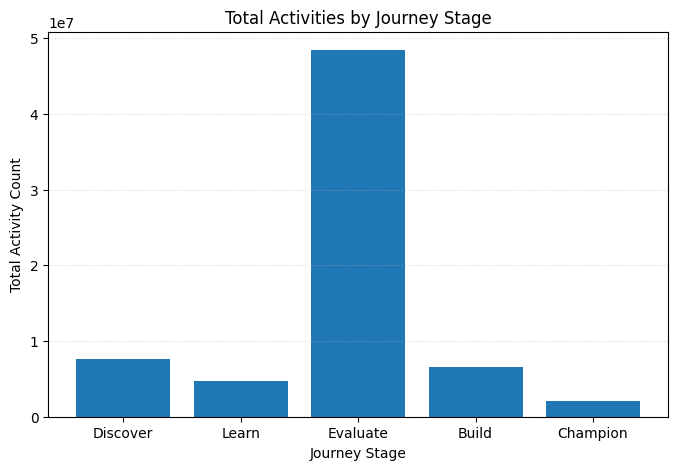

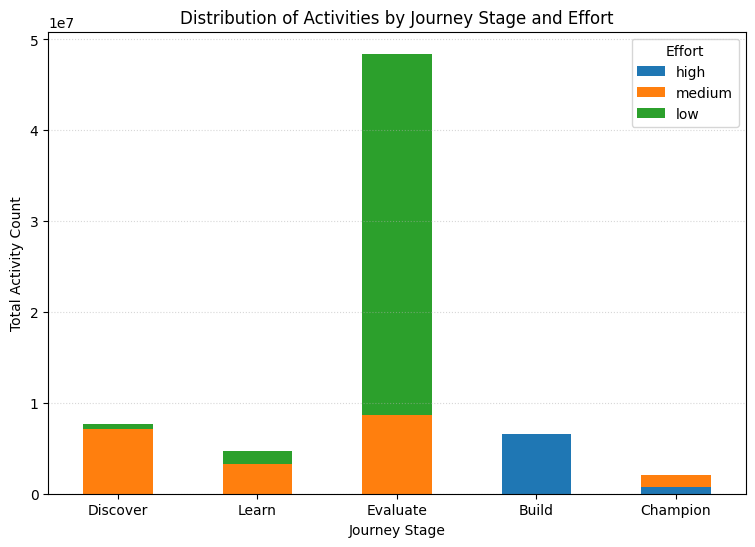

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# get counts by journey stage and effort from full dataset
stageEffortDf = con.execute("""
SELECT
    aje.journey_stage,
    aje.effort,
    COUNT(*) AS total_activity_count
FROM activity_final af
LEFT JOIN activity_journey_effort aje
    ON af.activity = aje.activity
GROUP BY aje.journey_stage, aje.effort
ORDER BY
    CASE aje.journey_stage
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
        ELSE 6
    END,
    CASE aje.effort
        WHEN 'high' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'low' THEN 3
        ELSE 4
    END
""").fetchdf()

# total by stage
stageTotalDf = (
    stageEffortDf.groupby("journey_stage", as_index=False)["total_activity_count"]
    .sum()
)

stageOrder = ["Discover", "Learn", "Evaluate", "Build", "Champion"]
effortOrder = ["high", "medium", "low"]

stageTotalDf["journey_stage"] = pd.Categorical(
    stageTotalDf["journey_stage"],
    categories=stageOrder,
    ordered=True
)
stageTotalDf = stageTotalDf.sort_values("journey_stage")

# graph 1: total activities by stage
plt.figure(figsize=(8,5))
plt.bar(stageTotalDf["journey_stage"], stageTotalDf["total_activity_count"])
plt.title("Total Activities by Journey Stage")
plt.xlabel("Journey Stage")
plt.ylabel("Total Activity Count")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="dotted", alpha=0.5)
plt.show()

# reshape for stacked bar chart
pivotDf = stageEffortDf.pivot(
    index="journey_stage",
    columns="effort",
    values="total_activity_count"
).fillna(0)

pivotDf = pivotDf.reindex(stageOrder)
pivotDf = pivotDf.reindex(columns=effortOrder)

# graph 2: stacked bar chart by stage and effort
pivotDf.plot(
    kind="bar",
    stacked=True,
    figsize=(9,6)
)
plt.title("Distribution of Activities by Journey Stage and Effort")
plt.xlabel("Journey Stage")
plt.ylabel("Total Activity Count")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="dotted", alpha=0.5)
plt.legend(title="Effort")
plt.show()

In [42]:
# create enriched activity table with journey stage and effort
con.execute("""
CREATE OR REPLACE TABLE activity_enriched AS
SELECT
    af.*,
    aje.journey_stage,
    aje.effort,
    CASE aje.journey_stage
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
    END AS journey_stage_num,
    CASE aje.effort
        WHEN 'low' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'high' THEN 3
    END AS effort_score
FROM activity_final af
LEFT JOIN activity_journey_effort aje
    ON af.activity = aje.activity
""")

100% ▕██████████████████████████████████████▏ (00:00:43.30 elapsed)     


In [ ]:
# developer-level journey score
# should journey stage num be highest historically or current
developerScoreDf = con.execute("""
SELECT
    dev_contact,
    COUNT(*) AS total_activities,
    COUNT(DISTINCT activity) AS unique_activities,
    COUNT(DISTINCT journey_stage) AS stages_touched,
    MAX(journey_stage_num) AS highest_stage_num,
    AVG(journey_stage_num) AS avg_stage_score,
    AVG(effort_score) AS avg_effort_score,
    SUM(journey_stage_num * effort_score) AS weighted_engagement_score
FROM activity_enriched
GROUP BY dev_contact
ORDER BY weighted_engagement_score DESC
""").fetchdf()

developerScoreDf.head()

100% ▕██████████████████████████████████████▏ (00:00:30.14 elapsed)       


,dev_contact,total_activities,unique_activities,stages_touched,highest_stage_num,avg_stage_score,avg_effort_score,weighted_engagement_score
0,5903679,2027375,2,2,3,2.999999,2.000000,12164246.0
1,5886356,789400,4,2,3,2.999992,1.999999,4736385.0
2,3931685,187095,1,1,3,3.000000,2.000000,1122570.0
3,2028858,142980,1,1,3,3.000000,2.000000,857880.0
4,6309430,121950,5,3,4,3.000722,1.995457,730316.0


In [ ]:
# assign developer segment based on behavior
# can change power champion
developerSegmentDf = con.execute("""
WITH developer_summary AS (
    SELECT
        dev_contact,
        COUNT(*) AS total_activities,
        COUNT(DISTINCT activity) AS unique_activities,
        COUNT(DISTINCT journey_stage) AS stages_touched,
        MAX(journey_stage_num) AS highest_stage_num,
        SUM(journey_stage_num * effort_score) AS weighted_engagement_score
    FROM activity_enriched
    GROUP BY dev_contact
)

SELECT
    *,
    CASE
        WHEN highest_stage_num = 5 AND weighted_engagement_score >= 50 THEN 'Power Champion'
        WHEN highest_stage_num = 5 THEN 'Community Champion'
        WHEN highest_stage_num = 4 THEN 'Builder'
        WHEN highest_stage_num = 3 THEN 'Evaluator'
        WHEN highest_stage_num = 2 THEN 'Learner'
        WHEN highest_stage_num = 1 THEN 'Discoverer'
        ELSE 'Unclassified'
    END AS developer_segment
FROM developer_summary
ORDER BY weighted_engagement_score DESC
""").fetchdf()

developerSegmentDf.head()

100% ▕██████████████████████████████████████▏ (00:00:11.76 elapsed)     


,dev_contact,total_activities,unique_activities,stages_touched,highest_stage_num,weighted_engagement_score,developer_segment
0,5903679,2027375,2,2,3,12164246.0,Evaluator
1,5886356,789400,4,2,3,4736385.0,Evaluator
2,3931685,187095,1,1,3,1122570.0,Evaluator
3,2028858,142980,1,1,3,857880.0,Evaluator
4,6309430,121950,5,3,4,730316.0,Builder


In [54]:
developerSegmentDf.groupby("developer_segment").size().reset_index(name="developer_count")

,developer_segment,developer_count
0,Builder,262584
1,Community Champion,824471
2,Discoverer,1548537
3,Evaluator,3497467
4,Learner,1299927
5,Power Champion,227292


In [55]:
# funnel: number of developers reaching each stage
funnelDf = con.execute("""
SELECT
    journey_stage,
    journey_stage_num,
    COUNT(DISTINCT dev_contact) AS developer_count
FROM activity_enriched
GROUP BY journey_stage, journey_stage_num
ORDER BY journey_stage_num
""").fetchdf()

funnelDf

,journey_stage,journey_stage_num,developer_count
0,Discover,1,6689900
1,Learn,2,1574211
2,Evaluate,3,4510789
3,Build,4,274927
4,Champion,5,1051763


In [ ]:
# funnel conversion rate from Discover
# with these, do we want to redefine our "score" from rarest to least rare (5-1)
discoverCount = funnelDf.loc[funnelDf["journey_stage"] == "Discover", "developer_count"].iloc[0]

funnelDf["conversion_from_discover"] = funnelDf["developer_count"] / discoverCount

funnelDf

,journey_stage,journey_stage_num,developer_count,conversion_from_discover
0,Discover,1,6689900,1.000000
1,Learn,2,1574211,0.235312
2,Evaluate,3,4510789,0.674269
3,Build,4,274927,0.041096
4,Champion,5,1051763,0.157217


In [58]:
# view stage transitions over time
transitionDf = con.execute("""
WITH ordered_activities AS (
    SELECT
        dev_contact,
        activity_date,
        journey_stage,
        journey_stage_num,
        LEAD(journey_stage) OVER (
            PARTITION BY dev_contact
            ORDER BY activity_date
        ) AS next_journey_stage,
        LEAD(journey_stage_num) OVER (
            PARTITION BY dev_contact
            ORDER BY activity_date
        ) AS next_journey_stage_num
    FROM activity_enriched
)

SELECT
    journey_stage AS from_stage,
    next_journey_stage AS to_stage,
    COUNT(*) AS transition_count
FROM ordered_activities
WHERE next_journey_stage IS NOT NULL
GROUP BY from_stage, to_stage
ORDER BY transition_count DESC
""").fetchdf()

transitionDf

100% ▕██████████████████████████████████████▏ (00:00:03.68 elapsed)     


,from_stage,to_stage,transition_count
0,Evaluate,Evaluate,41952524
1,Build,Build,6193882
2,Learn,Learn,2762664
3,Discover,Evaluate,2662164
4,Evaluate,Discover,2110666
5,Discover,Learn,1033420
6,Champion,Evaluate,928393
7,Evaluate,Champion,844485
8,Learn,Discover,668057
9,Champion,Champion,634347


In [60]:
# identify where developers stop
dropoffDf = con.execute("""
WITH developer_max_stage AS (
    SELECT
        dev_contact,
        MAX(journey_stage_num) AS max_stage_num
    FROM activity_enriched
    GROUP BY dev_contact
)

SELECT
    CASE max_stage_num
        WHEN 1 THEN 'Discover'
        WHEN 2 THEN 'Learn'
        WHEN 3 THEN 'Evaluate'
        WHEN 4 THEN 'Build'
        WHEN 5 THEN 'Champion'
    END AS final_stage,
    COUNT(*) AS developer_count
FROM developer_max_stage
GROUP BY final_stage, max_stage_num
ORDER BY max_stage_num
""").fetchdf()

dropoffDf

,final_stage,developer_count
0,Discover,1548537
1,Learn,1299927
2,Evaluate,3497467
3,Build,262584
4,Champion,1051763


In [63]:
# common journey paths by developer, memory-safe version
pathDf = con.execute("""
WITH first_stage AS (
    SELECT
        dev_contact,
        journey_stage,
        journey_stage_num,
        MIN(activity_date) AS first_stage_date
    FROM activity_enriched
    WHERE journey_stage IS NOT NULL
    GROUP BY dev_contact, journey_stage, journey_stage_num
),

paths AS (
    SELECT
        dev_contact,
        STRING_AGG(journey_stage, ' -> ' ORDER BY first_stage_date, journey_stage_num) AS journey_path
    FROM first_stage
    GROUP BY dev_contact
)

SELECT
    journey_path,
    COUNT(*) AS developer_count
FROM paths
GROUP BY journey_path
ORDER BY developer_count DESC
LIMIT 20
""").fetchdf()

pathDf

100% ▕██████████████████████████████████████▏ (00:00:10.34 elapsed)     


,journey_path,developer_count
0,Discover -> Evaluate,2688208
1,Discover,1548537
2,Discover -> Learn,1140815
3,Discover -> Evaluate -> Champion,713800
4,Evaluate,593638
5,Discover -> Build,154010
6,Evaluate -> Champion,136921
7,Learn,128222
8,Discover -> Learn -> Evaluate,68815
9,Discover -> Evaluate -> Learn,58870


In [65]:
# high effort concentration by developer
highEffortDf = con.execute("""
SELECT
    dev_contact,
    COUNT(*) AS high_effort_activity_count
FROM activity_enriched
WHERE effort = 'high'
GROUP BY dev_contact
ORDER BY high_effort_activity_count DESC
""").fetchdf()

highEffortDf.head(20)

,dev_contact,high_effort_activity_count
0,812707,36853
1,6502867,36747
2,7938574,20695
3,8582183,19294
4,6590114,18224
5,5944779,17144
6,5944795,15477
7,6149082,15027
8,9633953,12604
9,6522695,12015


In [66]:
# percent of high-effort activity from top developers
highEffortDf["cum_high_effort"] = highEffortDf["high_effort_activity_count"].cumsum()
highEffortDf["total_high_effort"] = highEffortDf["high_effort_activity_count"].sum()
highEffortDf["cum_percent"] = highEffortDf["cum_high_effort"] / highEffortDf["total_high_effort"]

highEffortDf.head(20)

,dev_contact,high_effort_activity_count,cum_high_effort,total_high_effort,cum_percent
0,812707,36853,36853,7368075,0.005002
1,6502867,36747,73600,7368075,0.009989
2,7938574,20695,94295,7368075,0.012798
3,8582183,19294,113589,7368075,0.015416
4,6590114,18224,131813,7368075,0.017890
5,5944779,17144,148957,7368075,0.020217
6,5944795,15477,164434,7368075,0.022317
7,6149082,15027,179461,7368075,0.024357
8,9633953,12604,192065,7368075,0.026067
9,6522695,12015,204080,7368075,0.027698


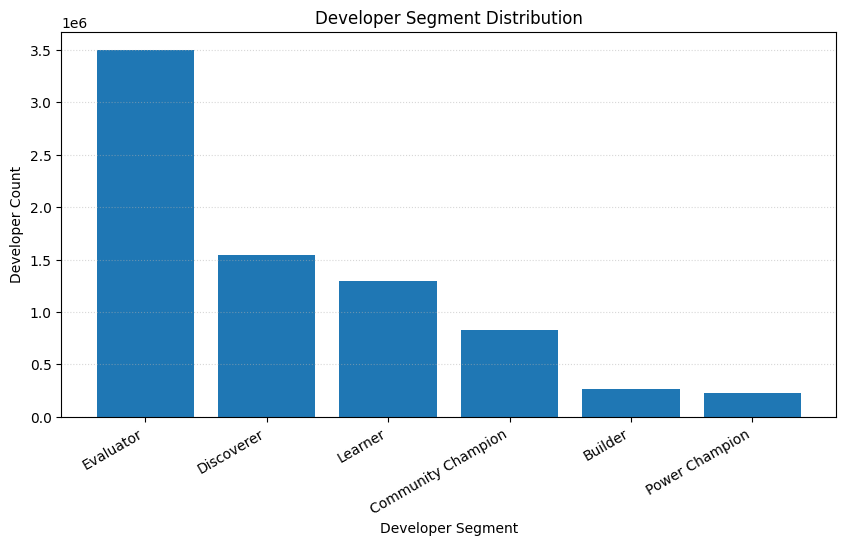

In [67]:
import matplotlib.pyplot as plt

# graph developer segment distribution
segmentCounts = (
    developerSegmentDf.groupby("developer_segment")
    .size()
    .reset_index(name="developer_count")
    .sort_values("developer_count", ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(segmentCounts["developer_segment"], segmentCounts["developer_count"])
plt.title("Developer Segment Distribution")
plt.xlabel("Developer Segment")
plt.ylabel("Developer Count")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="dotted", alpha=0.5)
plt.show()